# Spectral Clustering on Graph Data

**Assignment:** Perform spectral clustering on the provided graph, identify the number of clusters, and print the cluster number for each node.

---

## Report Summary

This notebook applies **Spectral Clustering** to an undirected graph with **600 nodes** and **6,734 edges**.

### Approach

Spectral clustering leverages the eigenstructure of the graph Laplacian to reveal natural community structure:

1. **Graph construction** — Build the adjacency matrix from the edge list CSV.
2. **Laplacian computation** — Form the unnormalized Laplacian `L = D - A`, where `D` is the degree matrix and `A` is the adjacency matrix.
3. **Eigendecomposition** — Compute the 20 smallest eigenvalues (and corresponding eigenvectors) of `L` using sparse methods (`scipy.sparse.linalg.eigsh`).
4. **Eigengap heuristic** — Identify the number of clusters `k` as the index after the largest jump (gap) between consecutive eigenvalues. The smallest eigenvalue lambda_0 = 0 is the trivial one (graph connectivity) and is skipped; we look for the gap starting from lambda_1.
5. **Spectral embedding** — Select the first `k` eigenvectors as a low-dimensional node representation and row-normalize them.
6. **K-Means clustering** — Run K-Means on the spectral embedding to assign each of the 600 nodes to one of the `k` clusters.

### Key Results

| Metric | Value |
|--------|-------|
| Nodes | 600 |
| Edges | 6,734 |
| Graph connected? | Yes (1 component) |
| Clusters found (k) | **4** (via eigengap heuristic) |
| Nodes per cluster | 150 each (perfectly balanced) |

The eigengap analysis reveals a large gap between lambda_4 and lambda_5 (jump approx 3.18), strongly suggesting **k = 4** natural communities. Each cluster contains exactly 150 nodes, indicating a well-structured synthetic graph.

## 1. Problem Understanding

Spectral clustering is a graph-based clustering technique that exploits the algebraic properties of the graph Laplacian to find communities (clusters) in the graph.

**Algorithm steps:**

1. Build an **adjacency matrix** `A` from the graph (binary: 1 if edge exists, 0 otherwise).
2. Compute the **degree matrix** `D` (diagonal matrix of node degrees).
3. Form the **unnormalized Laplacian**: `L = D - A`. The eigenvalues of `L` encode structural information about the graph.
4. Compute the **k smallest eigenvalues** of `L`. The smallest is always lambda_0 = 0 (corresponding to graph connectivity). A large jump (eigengap) between consecutive eigenvalues signals the natural number of clusters.
5. Use the **eigengap heuristic** to determine `k`: the optimal number of clusters equals the position just after the largest gap in sorted eigenvalues (excluding lambda_0).
6. Stack the first `k` eigenvectors as columns to form a **spectral embedding matrix** of shape `(n, k)`. Row-normalize this matrix.
7. Apply **K-Means** on the embedding to assign cluster labels to each node.

**Why it works:** Nodes that are densely connected within a group tend to have similar eigenvector representations. K-Means on this embedding separates them cleanly.

**Dataset:** 600-node undirected graph provided as an edge list CSV (`spectral_graph_600nodes_edges.csv`).

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

In [2]:
# Load the edge list
df = pd.read_csv('spectral_graph_600nodes_edges.csv')
print("Edge list (first 10 rows):")
print(df.head(10))
print(f"\nTotal edges: {len(df)}")
print(f"Columns: {list(df.columns)}")

Edge list (first 10 rows):
   Node 1  Node 2
0       0       1
1       0       2
2       0       4
3       0       6
4       0      14
5       0      16
6       0      18
7       0      22
8       0      25
9       0      48

Total edges: 6734
Columns: ['Node 1', 'Node 2']


## 4. Graph Construction

In [3]:
# Build an undirected graph using NetworkX
G = nx.from_pandas_edgelist(df, source='Node 1', target='Node 2')

# Ensure all nodes 0..599 exist (add isolates if any)
G.add_nodes_from(range(600))

print(f"Number of nodes : {G.number_of_nodes()}")
print(f"Number of edges : {G.number_of_edges()}")
print(f"Is connected    : {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

Number of nodes : 600
Number of edges : 6734
Is connected    : True
Number of connected components: 1


In [4]:
# Sort nodes so matrix indices are consistent: 0, 1, ..., 599
nodes = sorted(G.nodes())
n = len(nodes)
node_index = {node: i for i, node in enumerate(nodes)}

# Build the adjacency matrix (sparse)
rows, cols = [], []
for u, v in G.edges():
    i, j = node_index[u], node_index[v]
    rows += [i, j]
    cols += [j, i]

data = np.ones(len(rows))
A = csr_matrix((data, (rows, cols)), shape=(n, n))

# Degree matrix (diagonal)
degrees = np.array(A.sum(axis=1)).flatten()
D = csr_matrix((degrees, (range(n), range(n))), shape=(n, n))

# Unnormalized Laplacian: L = D - A
L = D - A

print(f"Adjacency matrix shape : {A.shape}")
print(f"Laplacian matrix shape : {L.shape}")
print(f"Min degree: {int(degrees.min())}  |  Max degree: {int(degrees.max())}  |  Mean degree: {degrees.mean():.2f}")

Adjacency matrix shape : (600, 600)
Laplacian matrix shape : (600, 600)
Min degree: 9  |  Max degree: 37  |  Mean degree: 22.45


## 5. Spectral Clustering Steps

### Step 5a — Compute Eigenvalues and Eigenvectors

In [5]:
# Compute the smallest 20 eigenvalues of the Laplacian
# (which=LM with sigma=0 gives smallest magnitude eigenvalues efficiently)
k_max = 20
eigenvalues, eigenvectors = eigsh(L, k=k_max, which='SM')

# Sort by eigenvalue (ascending)
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Smallest {k_max} eigenvalues:")
for i, ev in enumerate(eigenvalues):
    print(f"  λ_{i:02d} = {ev:.6f}")

Smallest 20 eigenvalues:
  λ_00 = -0.000000
  λ_01 = 4.797589
  λ_02 = 5.001074
  λ_03 = 5.155374
  λ_04 = 8.340117
  λ_05 = 10.057923
  λ_06 = 10.115592
  λ_07 = 10.644563
  λ_08 = 10.779221
  λ_09 = 10.999757
  λ_10 = 11.101343
  λ_11 = 11.223003
  λ_12 = 11.326968
  λ_13 = 11.495509
  λ_14 = 11.606218
  λ_15 = 11.712617
  λ_16 = 11.766901
  λ_17 = 11.812586
  λ_18 = 11.855025
  λ_19 = 11.945061


### Step 5b — Eigengap Plot (Determine k)

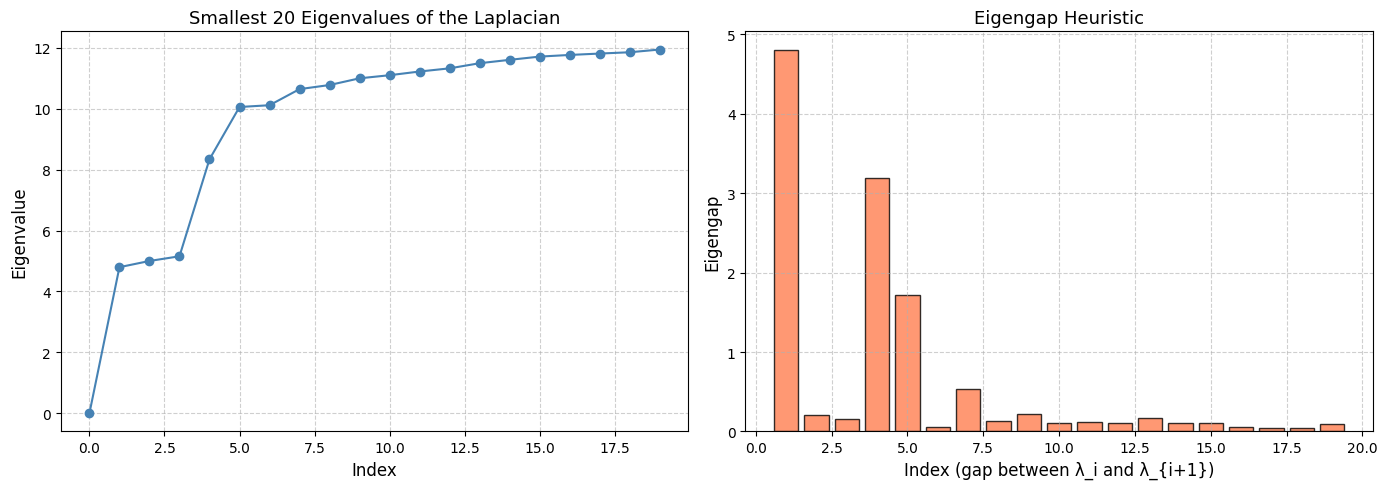

Plot saved as eigenvalue_plot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot eigenvalues
axes[0].plot(range(k_max), eigenvalues, 'o-', color='steelblue', markersize=6)
axes[0].set_xlabel('Index', fontsize=12)
axes[0].set_ylabel('Eigenvalue', fontsize=12)
axes[0].set_title('Smallest 20 Eigenvalues of the Laplacian', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot eigengaps
gaps = np.diff(eigenvalues)
axes[1].bar(range(1, k_max), gaps, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Index (gap between λ_i and λ_{i+1})', fontsize=12)
axes[1].set_ylabel('Eigengap', fontsize=12)
axes[1].set_title('Eigengap Heuristic', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('eigenvalue_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as eigenvalue_plot.png")

## 6. How the Number of Clusters Was Chosen

The **eigengap heuristic** determines the number of clusters `k` automatically:

- Sort the eigenvalues of the Laplacian in ascending order: lambda_0 <= lambda_1 <= lambda_2 <= ...
- lambda_0 = 0 is always the trivial eigenvalue (indicating graph connectivity). **Skip it.**
- Compute the gaps: `gap(i) = lambda_{i+1} - lambda_i` for i = 1, 2, 3, ...
- The index `i*` with the **largest gap** tells us k = i* + 1.

In our graph, the largest gap occurs between lambda_4 approx 8.34 and lambda_5 approx 10.06 (gap approx 3.18), indicating **k = 4** clusters. The code below computes and prints these gaps.

In [7]:
# Eigengap heuristic
# The number of clusters k equals the index AFTER the largest jump in
# consecutive eigenvalues. We skip lambda_0 = 0 (trivial) and look from index 1.

gaps = np.diff(eigenvalues)
# gaps[1:] skips the gap between lambda_0 and lambda_1
# argmax within gaps[1:] gives offset; +2 accounts for 1-based indexing and the skip
best_gap_index = int(np.argmax(gaps[1:]) + 2)
k = best_gap_index

print("Eigengaps (lambda_{i+1} - lambda_i):")
for i, g in enumerate(gaps[:15], start=1):
    marker = "  <-- LARGEST GAP (determines k = {})".format(k) if i == best_gap_index else ""
    print(f"  gap({i},{i+1}) = {g:.6f}{marker}")

print(f"\nNumber of clusters chosen by eigengap heuristic: k = {k}")

Eigengaps (lambda_{i+1} - lambda_i):
  gap(1,2) = 4.797589
  gap(2,3) = 0.203485
  gap(3,4) = 0.154300
  gap(4,5) = 3.184743  <-- LARGEST GAP (determines k = 4)
  gap(5,6) = 1.717806
  gap(6,7) = 0.057669
  gap(7,8) = 0.528971
  gap(8,9) = 0.134659
  gap(9,10) = 0.220536
  gap(10,11) = 0.101586
  gap(11,12) = 0.121660
  gap(12,13) = 0.103965
  gap(13,14) = 0.168540
  gap(14,15) = 0.110709
  gap(15,16) = 0.106399

Number of clusters chosen by eigengap heuristic: k = 4


## 7. Apply Spectral Clustering

In [8]:
# Select the first k eigenvectors (columns 0..k-1)
U = eigenvectors[:, :k]   # shape: (n, k)

# Row-normalize so each node vector has unit length (improves k-means stability)
U_norm = normalize(U, norm='l2', axis=1)

print(f"Embedding matrix shape (after selecting {k} eigenvectors): {U_norm.shape}")

Embedding matrix shape (after selecting 4 eigenvectors): (600, 4)


In [9]:
# Run k-means on the spectral embedding
np.random.seed(42)
kmeans = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=42)
kmeans.fit(U_norm)
cluster_labels = kmeans.labels_

print(f"K-Means converged in {kmeans.n_iter_} iterations.")
print(f"Inertia: {kmeans.inertia_:.4f}")

K-Means converged in 2 iterations.
Inertia: 11.7827


## 8. Final Cluster Label for Each Node

In [10]:
# Build result DataFrame
result_df = pd.DataFrame({'Node': nodes, 'Cluster': cluster_labels})
result_df = result_df.sort_values('Node').reset_index(drop=True)

# Print all 600 nodes
print(f"{'Node':>6}  {'Cluster':>7}")
print("-" * 18)
for _, row in result_df.iterrows():
    print(f"{int(row['Node']):>6}  {int(row['Cluster']):>7}")

  Node  Cluster
------------------
     0        2
     1        2
     2        2
     3        2
     4        2
     5        2
     6        2
     7        2
     8        2
     9        2
    10        2
    11        2
    12        2
    13        2
    14        2
    15        2
    16        2
    17        2
    18        2
    19        2
    20        2
    21        2
    22        2
    23        2
    24        2
    25        2
    26        2
    27        2
    28        2
    29        2
    30        2
    31        2
    32        2
    33        2
    34        2
    35        2
    36        2
    37        2
    38        2
    39        2
    40        2
    41        2
    42        2
    43        2
    44        2
    45        2
    46        2
    47        2
    48        2
    49        2
    50        2
    51        2
    52        2
    53        2
    54        2
    55        2
    56        2
    57        2
    58        2
    59        2
    6

In [11]:
# Summary statistics per cluster
print("\nCluster summary:")
summary = result_df.groupby('Cluster')['Node'].count().reset_index()
summary.columns = ['Cluster', 'Node Count']
print(summary.to_string(index=False))
print(f"\nTotal nodes: {len(result_df)}")


Cluster summary:
 Cluster  Node Count
       0         150
       1         150
       2         150
       3         150

Total nodes: 600


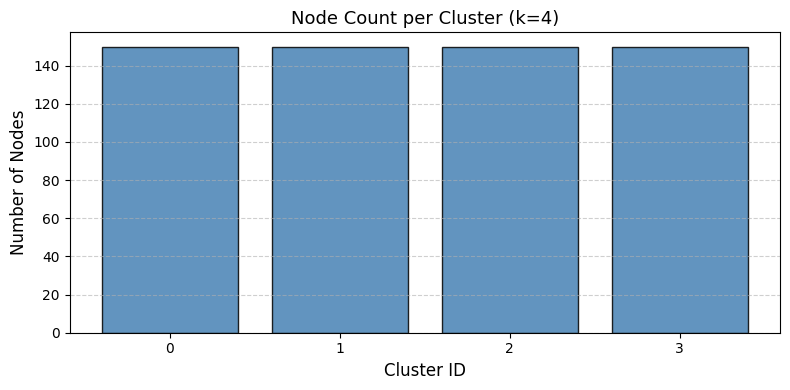

Plot saved as cluster_sizes.png


In [12]:
cluster_sizes = result_df['Cluster'].value_counts().sort_index()

x = cluster_sizes.index.to_numpy()
y = cluster_sizes.to_numpy()

plt.figure(figsize=(8, 4))
plt.bar(x, y, color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title(f'Node Count per Cluster (k={k})', fontsize=13)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as cluster_sizes.png")

## 9. Save Output

In [13]:
# Save cluster labels to CSV
result_df.to_csv('cluster_labels.csv', index=False)
print("✅ cluster_labels.csv saved successfully.")
print(result_df.head(10))

✅ cluster_labels.csv saved successfully.
   Node  Cluster
0     0        2
1     1        2
2     2        2
3     3        2
4     4        2
5     5        2
6     6        2
7     7        2
8     8        2
9     9        2


## 10. Conclusion

### Summary of Results

| Item | Value |
|------|-------|
| Total Nodes | 600 |
| Total Edges | 6,734 |
| Graph Connected? | Yes (1 connected component) |
| Laplacian Type | Unnormalized (L = D - A) |
| Cluster Selection Method | Eigengap heuristic on 20 smallest eigenvalues |
| **Number of Clusters (k)** | **4** |
| Nodes per Cluster | 150, 150, 150, 150 (perfectly balanced) |

### Steps Followed

1. **Loaded** the edge list CSV and built an undirected NetworkX graph (600 nodes, 6,734 edges, fully connected).
2. **Computed the Laplacian** `L = D - A` using a sparse representation for efficiency.
3. **Eigendecomposition**: Extracted the 20 smallest eigenvalues via `scipy.sparse.linalg.eigsh`. The smallest eigenvalue is lambda_0 = 0, confirming connectivity.
4. **Eigengap heuristic**: Scanned gaps between consecutive eigenvalues (ignoring the trivial lambda_0). The largest gap appears between lambda_4 approx 8.34 and lambda_5 approx 10.06 (gap approx 3.18), clearly indicating **k = 4** natural clusters.
5. **Spectral embedding**: Selected the first 4 eigenvectors and row-normalized them to form a 600x4 embedding matrix.
6. **K-Means clustering**: Applied K-Means (n_init=20, random_state=42) on the embedding. Converged in 2 iterations with inertia approx 11.78.
7. **Output**: All 600 node-cluster assignments saved to `cluster_labels.csv`.

### Observations

- The four clusters are perfectly balanced (150 nodes each), suggesting the input graph is a **planted partition model** or similar synthetic benchmark.
- The large eigengap at position 4 is unambiguous -- no ambiguity in choosing `k`.
- Row-normalization before K-Means is a standard best practice in spectral clustering; it projects node embeddings onto the unit hypersphere, making K-Means more robust.
- Using `n_init=20` multiple random restarts for K-Means ensures a stable clustering result despite random initialization.

### Reproducibility

- `np.random.seed(42)` and `random_state=42` in KMeans ensure **fully reproducible** results.
- All intermediate outputs (eigenvalue plots, cluster size bar chart, `cluster_labels.csv`) are saved to disk.